In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import sys
sys.path.insert(0, "/zhome/71/c/146676/texture_tomography/maptools")
import maptools
import os

%matplotlib inline
import matplotlib.pyplot as plt
import h5py
from datetime import datetime

maptools.job.info()
maptools.plot.dark()


hostname: n-62-11-21
SLURM_JOB_ID: None
SLURM_JOB_NODELIST: None
NPROCS: 24
Memory available: 800.221827072 GB


In [ ]:
# Good scanning 3dxrd files are:
scans = {
    "scan-0048.h5": (-0.75, -0.59),
    "scan-0049.h5": (-0.61, -0.45),
    "scan-0050.h5": (-0.47, -0.31),
    "scan-0051.h5": (-0.33, -0.17),
    "scan-0052.h5": (-0.19, -0.03),
    "scan-0053.h5": (-0.05, 0.11),
    "scan-0054.h5": (0.09, 0.25),
    "scan-0055.h5": (0.23, 0.39),
    "scan-0056.h5": (0.37, 0.53),
    "scan-0057.h5": (0.51, 0.67),
    "scan-0058.h5": (0.65, 0.75),
}


sample = "al1050_15pct_center_slice"
dataset = "scan-0053.h5"
maskfile_path = os.path.join(maptools.paths.PROCESS, "mask.npy")
dataroot = maptools.paths.RAW
analysisroot = os.path.join(maptools.paths.PROCESS, sample)
datapath = os.path.join(dataroot, sample, dataset)

In [3]:
updates = []
for k in maptools.constants.SCANRANGES.keys():
    pksfile = os.path.join(maptools.paths.PROCESS, sample, "segmented_peaks_" + k)
    with h5py.File(pksfile, "r") as f:
        for kk in f.keys():
            updates.append(f[kk].attrs["updated"])
d = sorted(datetime.fromisoformat(t) for t in updates)
delays = np.array([(d[i] - d[i - 1]).total_seconds() for i in range(1, len(d))])
if np.max(delays) > 100:
    raise ValueError(
        f"Max delay is too high: {np.max(delays)} seconds, are you sure the segmentaiton was done correctly?"
    )
print(f"Max delay: {np.max(delays)} seconds")
print(f"Min delay: {np.min(delays)} seconds")
print(f"Mean delay: {np.mean(delays)} seconds")
print(f"Median delay: {np.median(delays)} seconds")
print(f"Std delay: {np.std(delays)} seconds")


Max delay: 97.402019 seconds
Min delay: 52.628274 seconds
Mean delay: 76.72311199444444 seconds
Median delay: 81.83074049999999 seconds
Std delay: 14.861181105298241 seconds


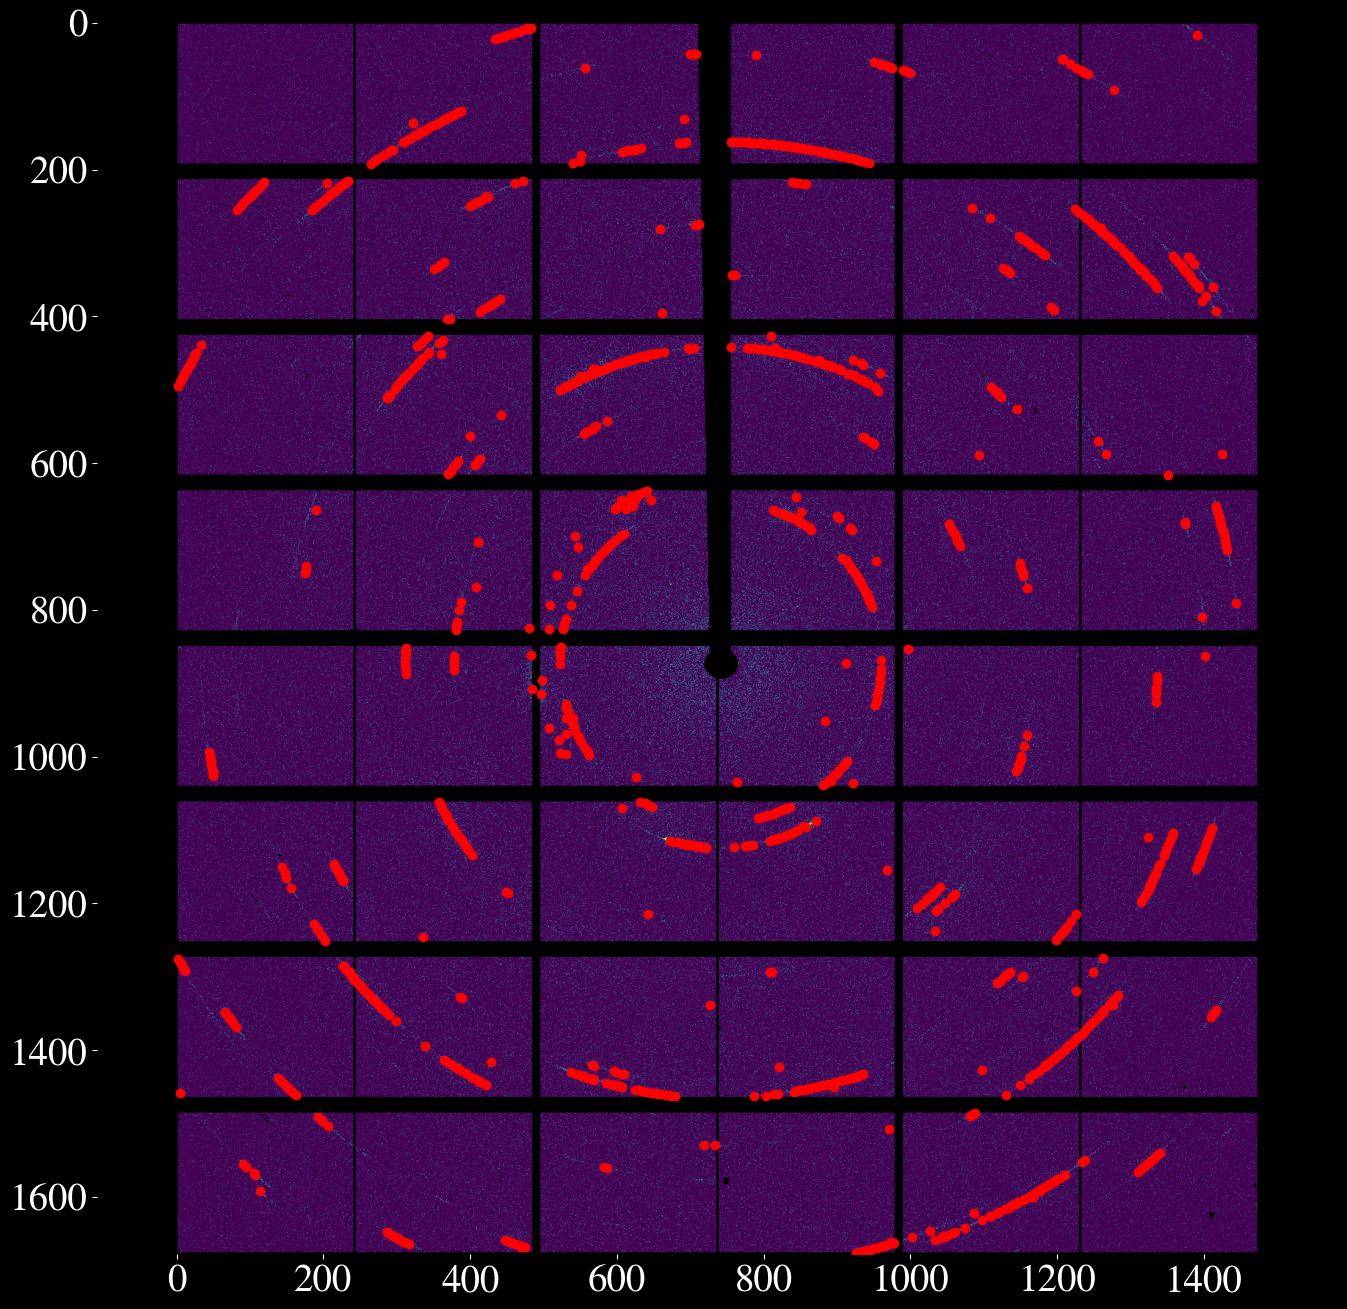

In [4]:
pksfile = os.path.join(
    maptools.paths.PROCESS, sample, "segmented_peaks_" + "scan-0050.h5"
)

key = "dty_m460_um"
with h5py.File(pksfile, "r") as f:
    h5path = f[key]["path_to_raw_frames"][()].decode()
    start_index = f[key]["frame_start_index"][()]
    end_index = f[key]["frame_end_index"][()]
    fc = f[key]["f_raw"][:]
    sc = f[key]["s_raw"][:]
    o_raw = f[key]["o_raw"][:]

with h5py.File(h5path, "r") as f:
    frame = f["entry/measurement/pilatus"][start_index]

maskfile = np.load(os.path.join(maptools.paths.PROCESS, "mask.npy"))
_mask = o_raw == o_raw.min()
fig, ax = plt.subplots(1, 1, figsize=(16, 16))
ax.scatter(fc[_mask], sc[_mask], marker="o", c="r", alpha=1)
_s = frame.copy().astype(np.float32)
_s[maskfile == 1] = np.nan
ax.imshow(_s, cmap="viridis", vmin=0, vmax=5)
ax.axis("equal")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()


In [5]:
# Validate that everythign was segmented in the same way
dtys = []
npks = []
for k in scans.keys():
    pksfile = os.path.join(maptools.paths.PROCESS, sample, "segmented_peaks_" + k)
    with h5py.File(pksfile, "r") as f:
        print(pksfile)
        for kk in f.keys():
            print(end=kk + ", ")

            assert f[kk]["segmenter_params/minpx"][()] == 1, "minpx is not 1"
            assert f[kk]["segmenter_params/threshold"][()] == 4, "threshold is not 4"

            dtys.append(f[kk]["dty"][0])
            npks.append(len(f[kk]["dty"]))

            if f[kk]["segmenter_params/minpx"][()] != 1:
                print(
                    f"\n\nminpx is not 1 but {f[kk]['segmenter_params/minpx'][()]}!!!!"
                )
            if f[kk]["segmenter_params/threshold"][()] != 4:
                print(
                    f"\n\nthreshold is not 4 but {f[kk]['segmenter_params/threshold'][()]}!!!!"
                )
    print("\n\n######################################################## ")

assert np.allclose(np.diff(np.unique(np.array(dtys).round(3))), 0.01), (
    "dtys are not consistent"
)
assert np.min(dtys) == -0.75, "min dty is not -0.75"
assert np.max(dtys) == 0.75, "max dty is not 0.75"
assert np.min(np.abs(dtys)) == 0.0, "min abs dty is not 0.0"
assert len(dtys) == 181, "dtys are missing"


/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/al1050_15pct_center_slice/segmented_peaks_scan-0048.h5
dty_m590_um, dty_m600_um, dty_m610_um, dty_m620_um, dty_m630_um, dty_m640_um, dty_m650_um, dty_m660_um, dty_m670_um, dty_m680_um, dty_m690_um, dty_m700_um, dty_m710_um, dty_m720_um, dty_m730_um, dty_m740_um, 

dty_m750_um, 

######################################################## 
/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/al1050_15pct_center_slice/segmented_peaks_scan-0049.h5
dty_m450_um, dty_m460_um, dty_m470_um, dty_m480_um, dty_m490_um, dty_m500_um, dty_m510_um, dty_m520_um, dty_m530_um, dty_m540_um, dty_m550_um, dty_m560_um, dty_m570_um, dty_m580_um, dty_m590_um, dty_m600_um, dty_m610_um, 

######################################################## 
/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/al1050_15pct_center_slice/segmented_peaks_scan-0050.h5
dty_m310_um, dty_m320_um, dty_m330_um, dty_m340_um, dty_m350_um, dty_m360_um, dty_m370_um, dty_m380_um, dty_m390_um, dty_m400_um, dty_m410_um, dty_m420_um, dty_m430_um, dty_m440_um, dty_m450_um, dty_m460_um, dty_m470_um, 

######################################################## 
/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_e

In [6]:
from skimage.transform import radon, iradon

Ny = len(np.unique(np.array(dtys).round(3)))
pizelsize = 0.01
image = np.zeros((Ny, Ny))

a, b = image.shape[0] // 2, image.shape[1] // 2

image[a - 50 : a + 50, b - 50 : b + 50] = 1

angles = np.arange(0.0, 360.0, 1.0)

sinogram = radon(image, theta=angles, circle=False)

nn = sinogram.shape[0]
dn = nn - Ny
pad = dn // 2
sinogram = sinogram[pad : -pad - 1, :]

profile_in_dty = np.sum(sinogram, axis=1)


(151, 151) (151, 360)


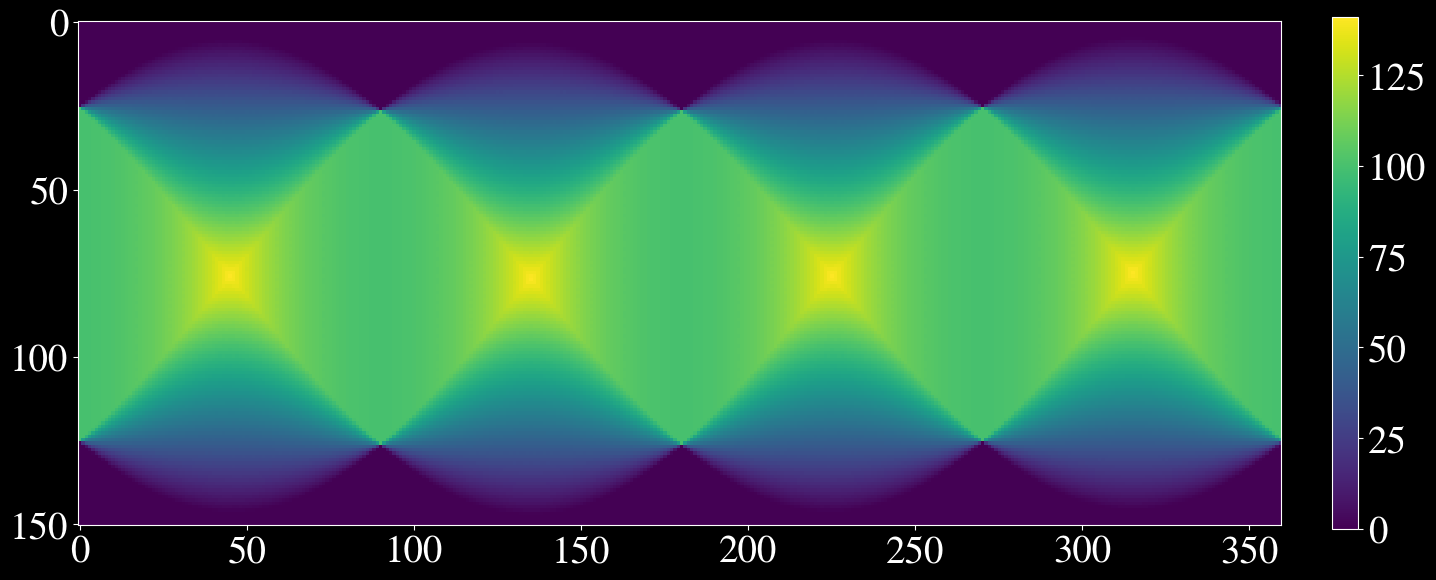

In [7]:
print(image.shape, sinogram.shape)
plt.style.use("dark_background")
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
im = ax.imshow(sinogram)
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()

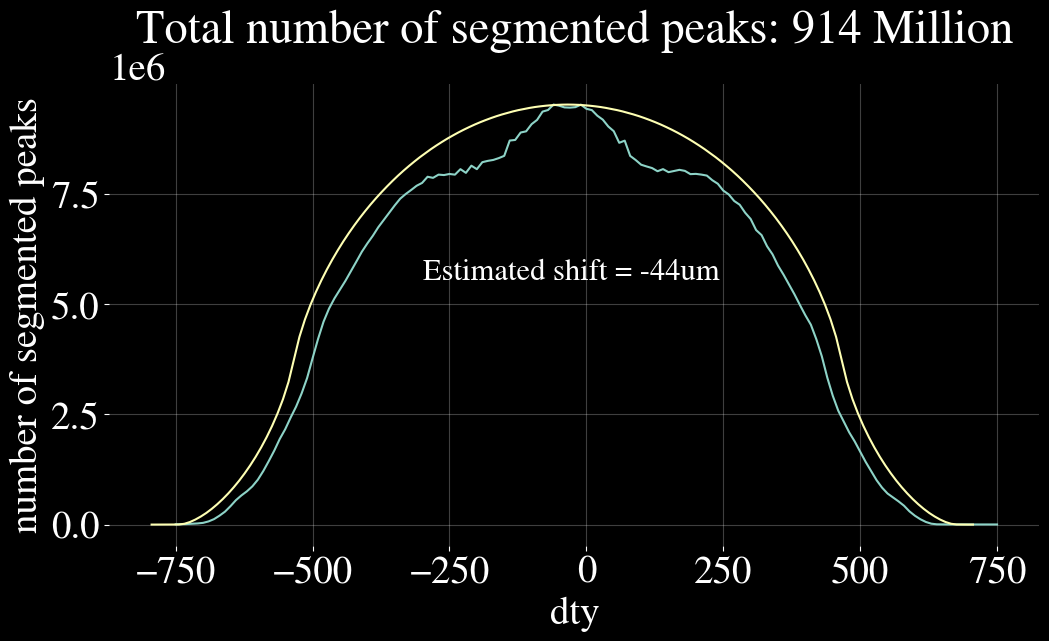

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
dtys_um = (np.array(dtys) * 1e3).round(1)
npks = np.array(npks)

# handle doublets in dty
unique_dtys, counts = np.unique(dtys_um, return_counts=True)
npks_new = np.zeros_like(unique_dtys)
for i in range(len(unique_dtys)):
    npks_new[i] = np.sum(npks[dtys_um == unique_dtys[i]]) / counts[i]

ax.plot(unique_dtys, npks_new)

shift = -44
ax.plot(
    unique_dtys + shift,
    (profile_in_dty / np.max(profile_in_dty)) * np.max(npks_new),
    label="Radon transform of a 1mm square",
)
ax.grid(True, alpha=0.25)
ax.text(
    -299,
    np.max(npks_new) * 0.6,
    f"Estimated shift = {shift}um",
    fontsize=22,
    ha="left",
    va="center",
)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlabel("dty")
ax.set_ylabel("number of segmented peaks")
ax.set_title(
    f"Total number of segmented peaks: {np.round(np.sum(npks) / 1e6).astype(int)} Million"
)
plt.show()